In [4]:
##importing libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=8,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=8,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [7]:
training_set


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [8]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[ 87.75  83.25  81.25]
   [166.75 161.75 157.75]
   [161.5  156.5  152.5 ]
   ...
   [158.25 150.25 147.25]
   [158.   150.   147.  ]
   [161.25 153.25 150.25]]

  [[ 87.5   82.75  80.75]
   [165.   160.   156.  ]
   [164.5  159.5  155.5 ]
   ...
   [155.5  147.5  144.5 ]
   [157.25 149.25 146.25]
   [161.5  153.5  150.5 ]]

  [[ 89.25  84.25  81.5 ]
   [165.25 160.25 156.25]
   [165.75 160.75 156.75]
   ...
   [156.5  148.5  145.5 ]
   [158.   150.   147.  ]
   [162.75 154.75 151.75]]

  ...

  [[ 67.5   63.    61.  ]
   [134.25 129.25 125.25]
   [135.75 130.75 126.75]
   ...
   [101.5   96.5   92.5 ]
   [104.    99.    95.  ]
   [106.5  101.5   97.5 ]]

  [[ 70.5   66.    64.  ]
   [139.   134.   130.  ]
   [134.25 129.25 125.25]
   ...
   [101.75  96.75  92.75]
   [105.25 100.25  96.25]
   [106.75 101.75  97.75]]

  [[ 74.5   69.75  67.25]
   [146.75 141.75 137.75]
   [135.25 130.25 126.25]
   ...
   [104.    99.    95.  ]
   [107.75 102.75  98.75]
   [104.75  99.75  9

In [9]:
#building model
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [10]:
model = Sequential()

In [11]:
#building convolution layer
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

C:\Users\BIT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [14]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [15]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [16]:
model.add(Dropout(0.25)) 

In [17]:
model.add(Flatten())

In [18]:
model.add(Dense(units=512,activation='relu'))

In [19]:
model.add(Dropout(0.3))

In [20]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          19,494 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,896,710 (11.05 MB)

 Trainable params: 2,896,710 (11.05 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=5)

Epoch 1/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 1913s 217ms/step - accuracy: 0.5623 - loss: 1.5088 - val_accuracy: 0.8235 - val_loss: 0.5566
Epoch 2/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 2199s 250ms/step - accuracy: 0.8555 - loss: 0.4612 - val_accuracy: 0.8756 - val_loss: 0.4030
Epoch 3/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 2049s 233ms/step - accuracy: 0.9148 - loss: 0.2717 - val_accuracy: 0.9046 - val_loss: 0.3226
Epoch 4/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 2090s 238ms/step - accuracy: 0.9413 - loss: 0.1819 - val_accuracy: 0.9441 - val_loss: 0.1730
Epoch 5/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 1949s 222ms/step - accuracy: 0.9559 - loss: 0.1358 - val_accuracy: 0.9542 - val_loss: 0.1539


In [24]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

8787/8787 ━━━━━━━━━━━━━━━━━━━━ 535s 61ms/step - accuracy: 0.9741 - loss: 0.0811


In [25]:
print(train_loss,train_acc)

0.08110475540161133 0.9741233587265015


In [26]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.9542 - loss: 0.1539


In [27]:
print(val_loss,val_acc)

0.15391847491264343 0.9541884660720825


In [28]:
model.save("trained_model.keras")

In [29]:
training_history.history

{'accuracy': [0.5622875094413757,
  0.8554804921150208,
  0.9148018956184387,
  0.9413045048713684,
  0.9558717012405396],
 'loss': [1.5087817907333374,
  0.4612267315387726,
  0.27168726921081543,
  0.18185211718082428,
  0.1357843577861786],
 'val_accuracy': [0.8235260844230652,
  0.8755975365638733,
  0.9046210050582886,
  0.9440587162971497,
  0.9541884660720825],
 'val_loss': [0.5565882325172424,
  0.4029821753501892,
  0.32259121537208557,
  0.17296530306339264,
  0.15391837060451508]}

In [30]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [31]:
training_history.history['val_accuracy']

[0.8235260844230652,
 0.8755975365638733,
 0.9046210050582886,
 0.9440587162971497,
 0.9541884660720825]

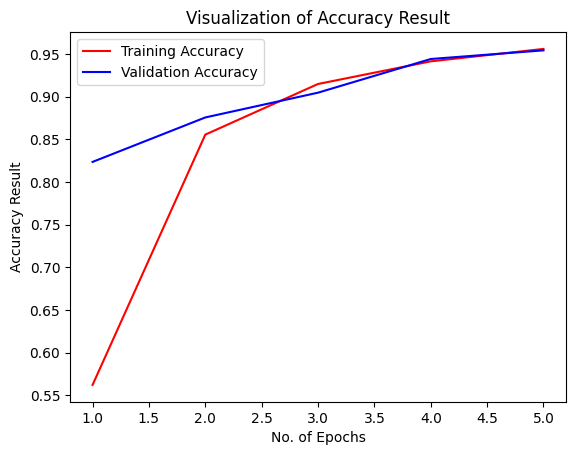

In [34]:
#accuracy visualisation
epochs = [i for i in range(1,len(training_history.history['accuracy'])+1)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

In [35]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [36]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [37]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 110s 199ms/step


(array([[1.0000000e+00, 9.6317897e-13, 4.1048812e-14, ..., 6.5729995e-20,
         4.3420232e-18, 6.0568878e-17],
        [9.9994111e-01, 1.7583851e-08, 5.1002452e-10, ..., 2.9005166e-14,
         1.3916182e-12, 9.5331791e-11],
        [1.0000000e+00, 1.0041021e-14, 2.2722063e-15, ..., 9.9093829e-26,
         1.7946291e-20, 5.3042358e-17],
        ...,
        [9.2130627e-08, 4.2534793e-09, 6.1351551e-07, ..., 1.0431238e-09,
         1.3540891e-07, 9.8251879e-01],
        [1.1291378e-08, 6.7403986e-12, 2.1673075e-07, ..., 6.5870615e-11,
         4.4542121e-09, 9.9918419e-01],
        [1.8121857e-13, 7.0576339e-15, 3.5948032e-13, ..., 2.7934948e-14,
         7.5486076e-11, 9.9999678e-01]], shape=(17572, 38), dtype=float32),
 (17572, 38))

In [38]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [39]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [40]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [41]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [42]:
from sklearn.metrics import classification_report,confusion_matrix

In [43]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.94      0.94       504
                                 Apple___Black_rot       0.99      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.99      0.92      0.95       440
                                   Apple___healthy       0.89      0.97      0.92       502
                               Blueberry___healthy       0.97      0.99      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       421
                 Cherry_(including_sour)___healthy       0.93      0.99      0.96       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.78      0.87       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.76      0.99      0.

In [44]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[474,   0,   0, ...,   0,   0,   0],
       [  3, 489,   0, ...,   0,   0,   0],
       [ 12,   0, 406, ...,   0,   0,   1],
       ...,
       [  0,   0,   0, ..., 482,   1,   0],
       [  0,   0,   0, ...,   0, 446,   0],
       [  0,   0,   1, ...,   0,   0, 469]], shape=(38, 38))

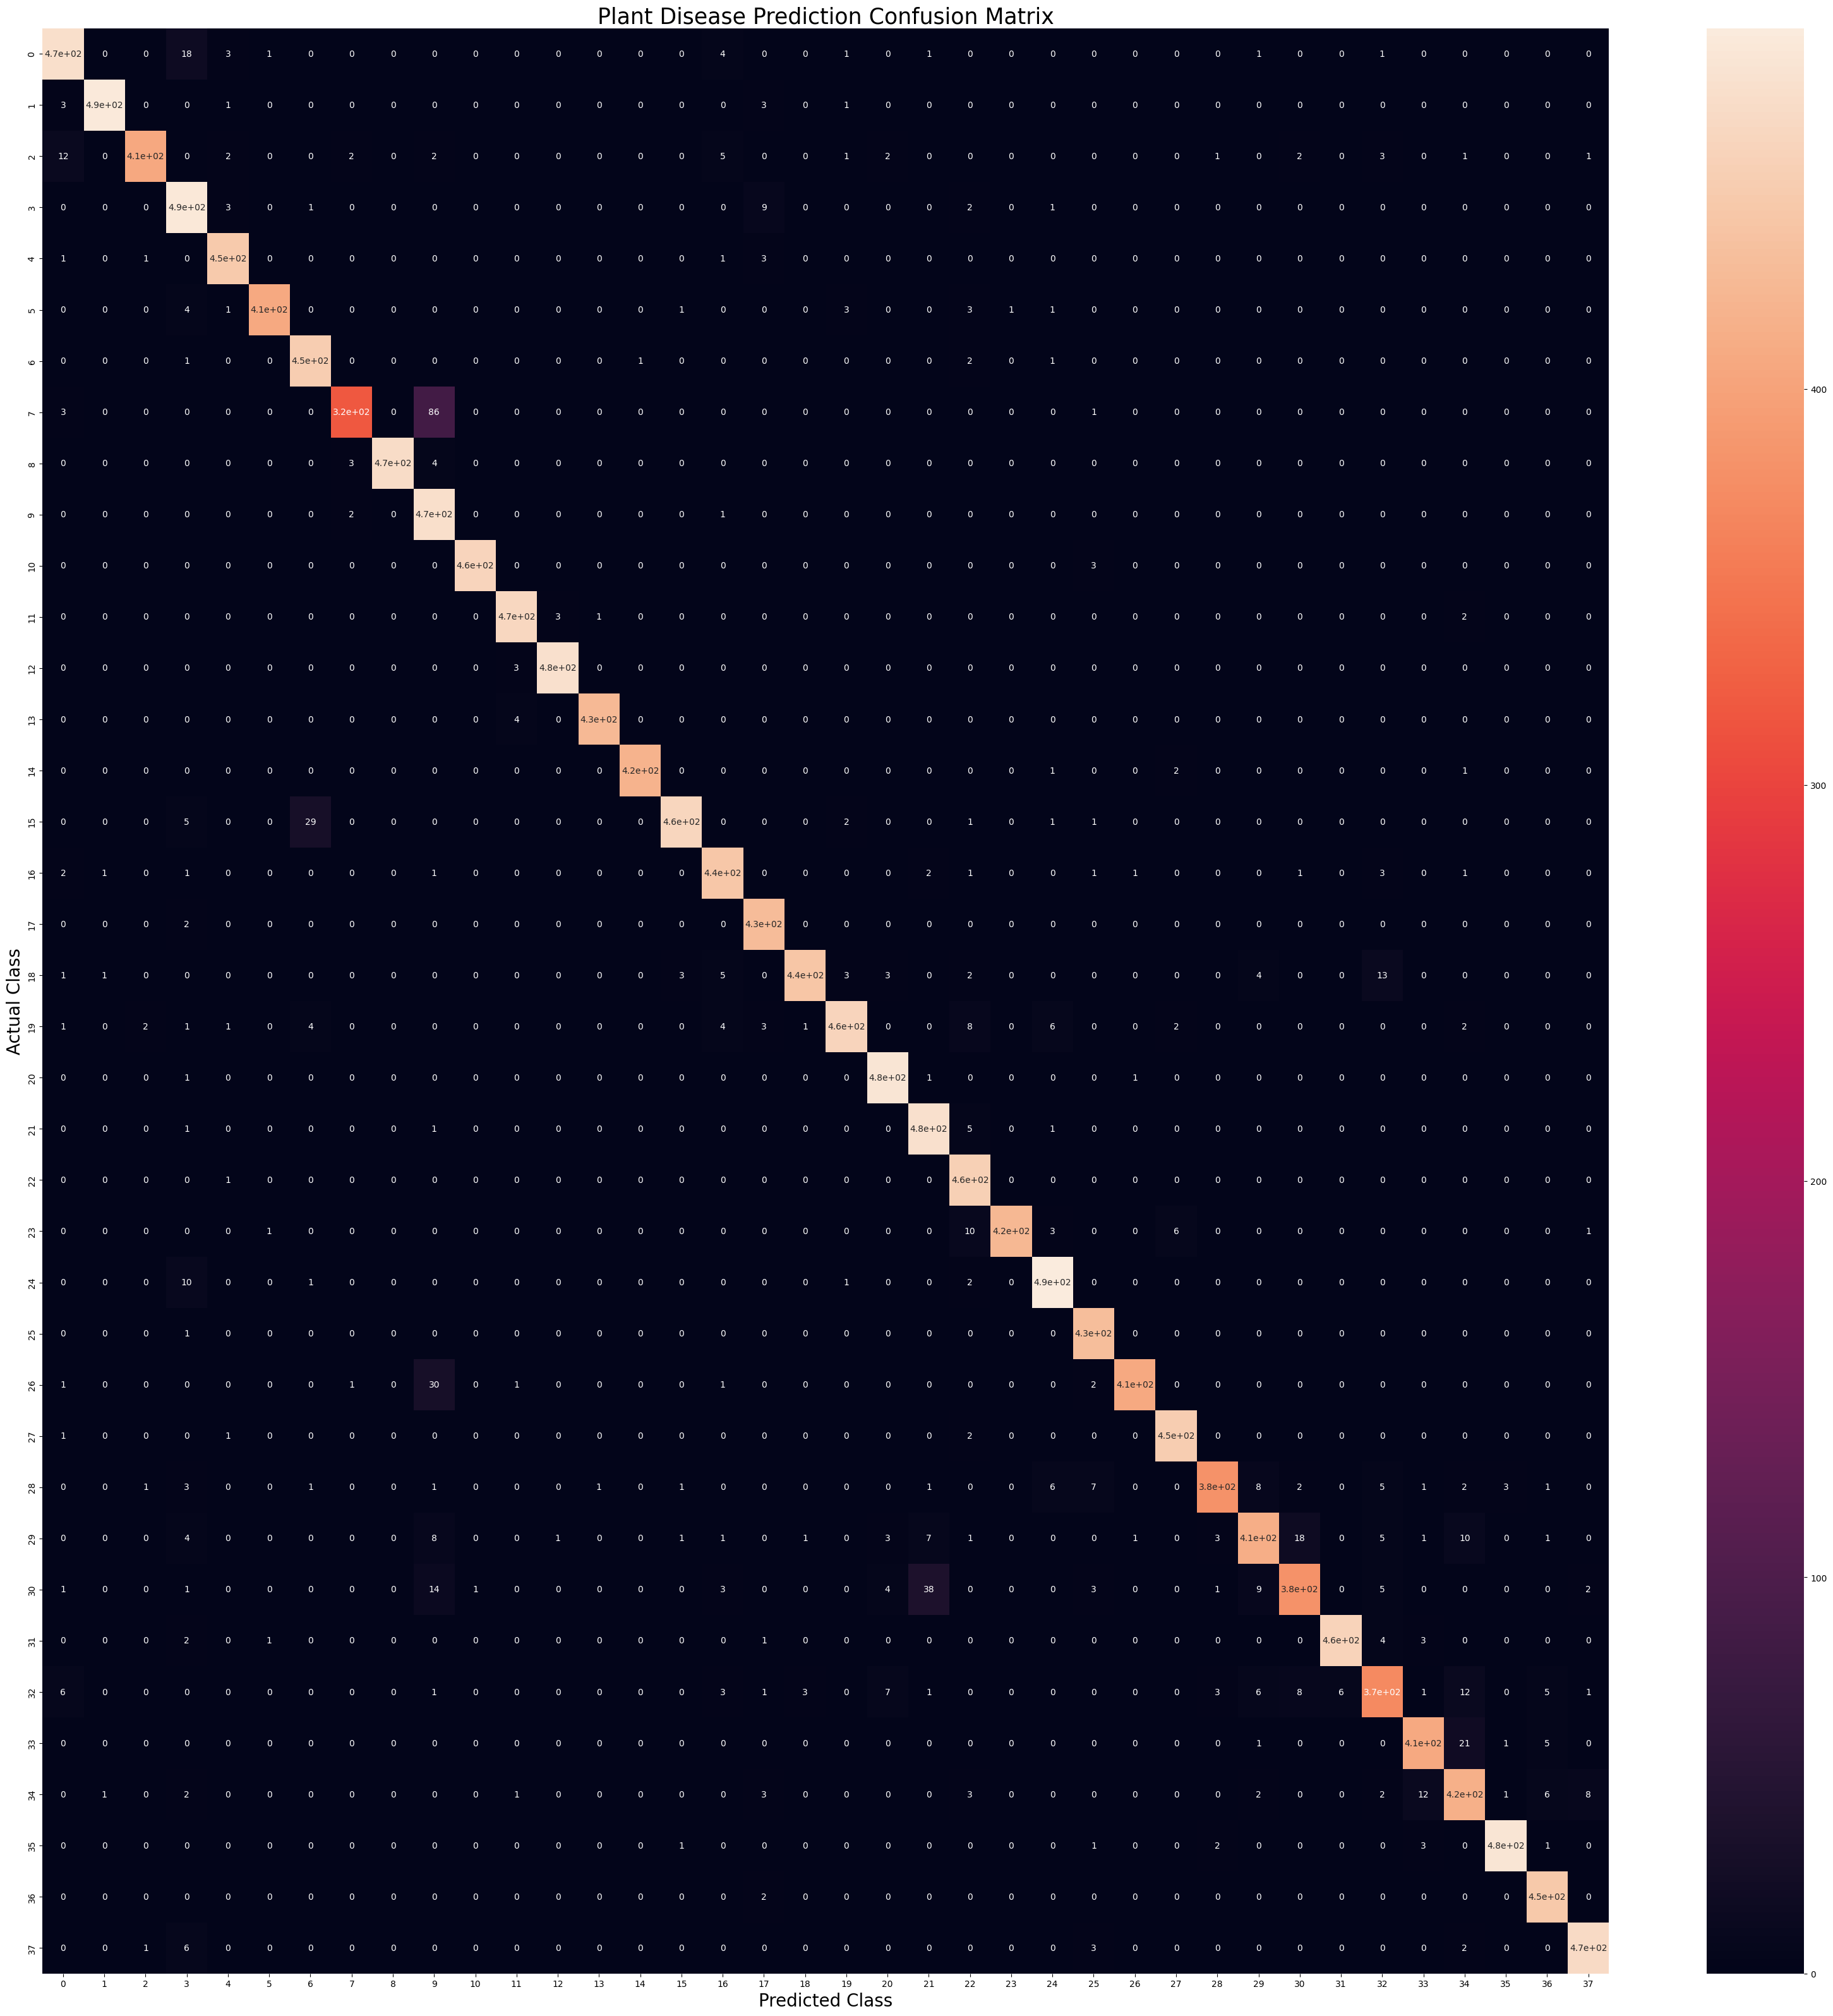

In [45]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()